# Task 2: Paid Social A/B Campaign Analysis

A segment of non-customers was exposed to two Paid Social campaigns on Facebook during **March 2017**:

| Group | Creative |
|-------|----------|
| Treatment A | Metal card creative |
| Treatment B | Standard card creative |

Each treatment was shown to 50% of the audience (random split).

This notebook covers: how I reverse-engineered the business intent behind the experiment, what success actually means here, whether observed differences are statistically meaningful, and what I would fix in future experiments.

## Setup

In [2]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare

import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.cleaning import fix_date_column
from src.statistical_tests import chi2_test, chi2_power_report, chi2_residuals

sns.set_theme(style='whitegrid', palette='Set2')

## Data Loading & Validation

Before anything else: experiment integrity. A/B test results are only meaningful if the experiment was run cleanly. I check:
- No user appears in both groups
- No user signed up for both products simultaneously
- Dates are valid and within the March 2017 window
- The 50/50 split was respected (Sample Ratio Mismatch check)
- Country-level splits are balanced

In [3]:
experiment = pd.read_csv("../data/part_b_dataset.csv")
experiment.head()

,userid,country,day_exposed_to_ad,treatment,signed_up_metal,signed_up_standard
0,e0912256-b48a-45c0-afec-23350d341abd,Spain,2017-03-01,Standard,0,1
1,321c18f1-c58e-488d-a60a-462dfc9d38aa,Italy,2017-03-10,Standard,0,0
2,3d03c163-d14b-49da-873a-a54cc3b400e3,Italy,2017-03-24,Metal,0,1
3,3acb5a84-4375-405b-9a8b-bfb8979ab9bc,Spain,2017-03-06,Standard,0,1
4,1b488764-6874-4483-8e70-815feb07b154,Italy,2017-03-03,Metal,0,0


In [4]:
df = fix_date_column(experiment, 'day_exposed_to_ad')
print(f"Date range: {df['day_exposed_to_ad'].min().date()} -> {df['day_exposed_to_ad'].max().date()}")
print(f"Total users: {df['userid'].nunique():,}")

[fix_date_column] dropped 0 row(s); 5000/5000 remain.
Date range: 2017-03-01 -> 2017-03-31
Total users: 5,000


In [5]:
duplicate_users = duckdb.query("""
    select userid from df group by 1 having count(*) > 1
""").to_df()

dual_signups = duckdb.query("""
    select * from df where signed_up_metal = 1 and signed_up_standard = 1
""").to_df()

print(f"Duplicate user IDs: {len(duplicate_users)} (expected 0)")
print(f"Dual signup user IDs: {len(dual_signups)} (expected 0)")

Duplicate user IDs: 0 (expected 0)
Dual signup user IDs: 0 (expected 0)


#### Sample Ratio Mismatch (SRM) Check

If the split deviates from 50/50, randomisation may have been broken, making any downstream results unreliable. I use a chi-square goodness-of-fit test.

In [6]:
split = df.groupby('treatment')['userid'].nunique().reset_index(name='n')
display(split.assign(share=lambda x: x['n'] / x['n'].sum()))

n_total = split['n'].sum()
stat, p = chisquare(f_obs=split['n'].values, f_exp=[n_total / 2, n_total / 2])
print(f"\nSRM Test  ->  chi2={stat:.4f}, p={p:.4f}")
print("Conclusion:", "SRM detected. Investigate randomisation." if p < 0.05 else "No SRM. Split looks clean.")

,treatment,n,share
0,Metal,2463,0.4926
1,Standard,2537,0.5074



SRM Test  ->  chi2=1.0952, p=0.2953
Conclusion: No SRM. Split looks clean.


#### Country-Level Balance

The experiment covers Spain and Italy. An imbalance within either country would suggest non-random assignment.

In [7]:
duckdb.query("""
    select
        treatment,
        country,
        count(distinct userid) as user_count,
        round(count(distinct userid) / sum(count(distinct userid)) over (partition by country), 2) as pct_within_country
    from df
    group by 1, 2
    order by 2, 1
""").to_df()

,treatment,country,user_count,pct_within_country
0,Metal,Italy,1247,0.49
1,Standard,Italy,1283,0.51
2,Metal,Spain,1216,0.49
3,Standard,Spain,1254,0.51


#### Temporal Exposure Pattern

One treatment being paused mid-month, a spike on a specific day, or systematic divergence over time would indicate a problem with experiment execution.

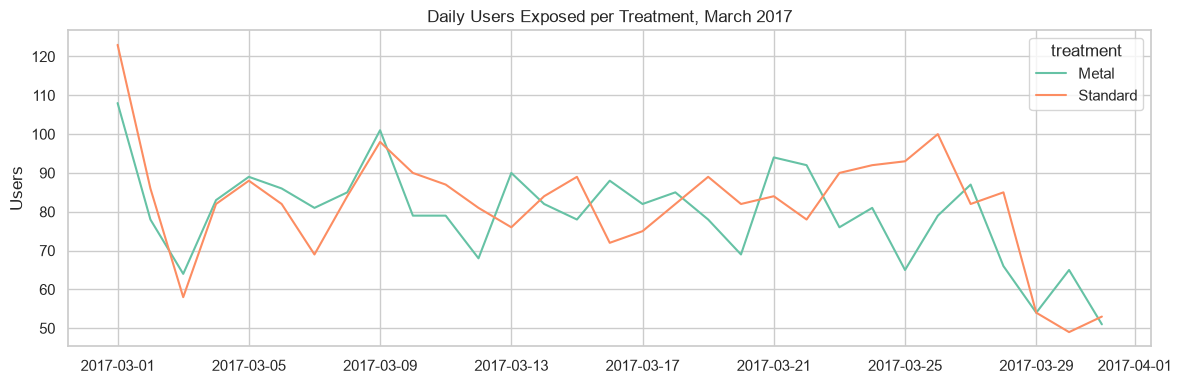

In [8]:
daily = (
    df.groupby(['day_exposed_to_ad', 'treatment'])['userid']
    .count()
    .reset_index(name='users')
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=daily, x='day_exposed_to_ad', y='users', hue='treatment', ax=ax)
ax.set_title('Daily Users Exposed per Treatment, March 2017')
ax.set_xlabel('')
ax.set_ylabel('Users')
plt.tight_layout()
plt.show()

No duplicate users, no SRM, balanced country splits, no temporal anomalies. The experiment is clean.

---

## What Are We Actually Testing?

The dataset was clean. No date issues, no contamination, perfectly balanced splits. The challenge here is not the data. It is understanding what this experiment was actually designed to measure.

We have two creatives (Metal and Standard) shown to a 50/50 split of non-customers. **No holdout group.** We are not measuring whether paid social works. We are measuring which creative performs better. Narrower question, different interpretation.

### What kind of campaign was this?

We were not given campaign metadata: no CTR, no impressions, no campaign objective from Meta. But this matters. A traffic campaign and a conversion campaign are optimised differently and attract different types of users.

- **Traffic campaign**: Meta optimises for reach and clicks. The goal is volume, getting people into the funnel. Signup as a success signal makes sense here.
- **Conversion campaign**: Meta optimises for a conversion event. If that event is signup, Meta finds the cheapest-to-register users, not the most valuable ones. From Task 1, 63% of signups never transact. Paying conversion CPAs for that population does not hold up. First transaction or KYC completion would have been the right event.

Based on the available data (signup is our only signal, no downstream funnel data), **I am treating this as a traffic campaign**. Signup as a top-of-funnel metric fits. If this were a conversion campaign, we would need monetary metrics and we would be working with incomplete data either way.

### What information is missing?

Without clicks and lower-funnel data, there is no visibility into the signup flow. Users might have converted directly or dropped off at the paywall. We do not know. The dataset captures outcomes, not journeys.

---

## Defining Success Metrics: the Paywall Problem

Before running any tests, there is a structural issue to address.

Both creatives led to the same signup flow. No evidence the paywall was product-specific. A Metal-creative user could still choose Standard at signup, and vice versa. This creates a metric design problem.

`any_signup` blends two things into one:
1. Whether the creative brought someone into the funnel at all
2. Which product they chose once they arrived

These are separate questions: creative effectiveness vs. product preference at the paywall. Measuring only `any_signup` makes it impossible to say which creative actually worked. The split was fine. The outcome variable was just too broad.

I define three mutually exclusive outcomes instead:

| Metric | Definition | Why it matters |
|--------|------------|-----------------|
| `target_signup` | Signed up for the same product as the creative shown | Direct measure of creative effectiveness |
| `cross_signup` | Signed up for the opposite product | Captures paywall leakage |
| `no_signup` | Did not sign up for either | No conversion |

`target_signup` is the cleanest measure of whether the creative did its job. `cross_signup` is the signal that the paywall did not enforce the creative's intent. `any_signup` is tracked as a secondary metric.

In [9]:
df['any_signup'] = ((df['signed_up_metal'] + df['signed_up_standard']) >= 1).astype(int)
df['no_signup']  = ((df['signed_up_metal'] + df['signed_up_standard']) == 0).astype(int)

df['target_signup'] = df.apply(
    lambda r: r['signed_up_metal'] if r['treatment'] == 'Metal' else r['signed_up_standard'],
    axis=1
)
df['cross_signup'] = df.apply(
    lambda r: r['signed_up_standard'] if r['treatment'] == 'Metal' else r['signed_up_metal'],
    axis=1
)

summary = df.groupby('treatment')[['no_signup', 'target_signup', 'cross_signup', 'any_signup']].mean().round(4)
summary['n'] = df.groupby('treatment')['userid'].count()
summary

,no_signup,target_signup,cross_signup,any_signup,n
treatment,,,,,
Metal,0.7950,0.0666,0.1384,0.2050,2463
Standard,0.7801,0.1529,0.0670,0.2199,2537


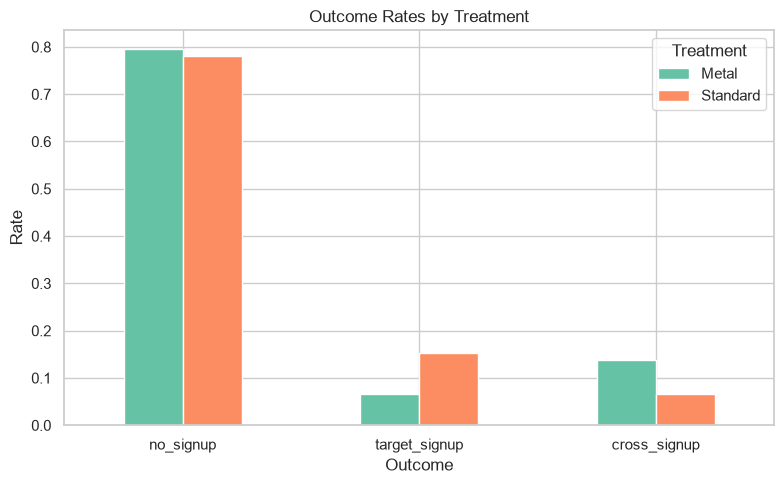

In [10]:
plot_data = summary[['no_signup', 'target_signup', 'cross_signup']].T.rename(columns=str)

ax = plot_data.plot(kind='bar', figsize=(8, 5), rot=0)
ax.set_title('Outcome Rates by Treatment')
ax.set_ylabel('Rate')
ax.set_xlabel('Outcome')
ax.legend(title='Treatment')
plt.tight_layout()
plt.show()

Standard has a higher `target_signup` rate (15.3%) vs Metal (6.7%). Metal has a higher `cross_signup` rate (13.8%): Metal-exposed users converted to Standard more often than to Metal itself. Overall signup rates are similar. The question is whether these differences are statistically meaningful.

---

## Assumptions

| # | Assumption | Why I make it | Risk if wrong |
|---|-----------|----------------|---------------|
| 1 | Random assignment was correctly implemented | SRM test (p = 0.30) and country-level splits (~49/51) are consistent with correct randomisation | Group composition would be biased; observed differences could reflect selection rather than creative effect |
| 2 | No cross-contamination between groups | Standard Facebook campaign architecture enforces mutually exclusive ad sets when properly configured; cannot verify from the data alone | If users saw both creatives, the causal interpretation breaks down |
| 3 | Sign-up is a meaningful proxy for campaign effectiveness | It is the only downstream outcome in the dataset; appropriate for a traffic campaign | Ignores post-signup quality (KYC completion, activation, first transaction). More signups with fewer activations looks better here but performs worse on revenue |
| 4 | The sign-up outcome is correctly attributed | Assumes proper attribution logic (last-click or view-through within the campaign window) | If one creative had a different attribution window, the comparison is not apples-to-apples |
| 5 | Spain and Italy are comparable enough to pool | Country-level splits and raw rates are similar | If creative effectiveness differs by market, pooled results mask that, addressed in Section 5 with country-level tests |

---

## Statistical Framework

All outcomes are categorical and I am comparing proportions across two independent groups. Chi-square test of independence is the right choice: no normality assumption, works for binary and multi-category outcomes, all expected cell counts are well above 5.

Every test is complemented with Cohen's w. A statistically significant result with a negligible effect size is not actionable.

I run three hypothesis tests:

| Test | Outcome | Question |
|------|---------|----------|
| H1 | `any_signup` | Did the campaigns differ in overall sign-up rate? |
| H2 | `target_signup` | Did the creative treatment affect on-target conversion? |
| H3 | `no_signup`, `target_signup`, `cross_signup` (3-way) | Did the full outcome distribution differ across treatments? |

Each test is run pooled across both countries, then separately per country to validate assumption 5. Alpha = 0.05 throughout.

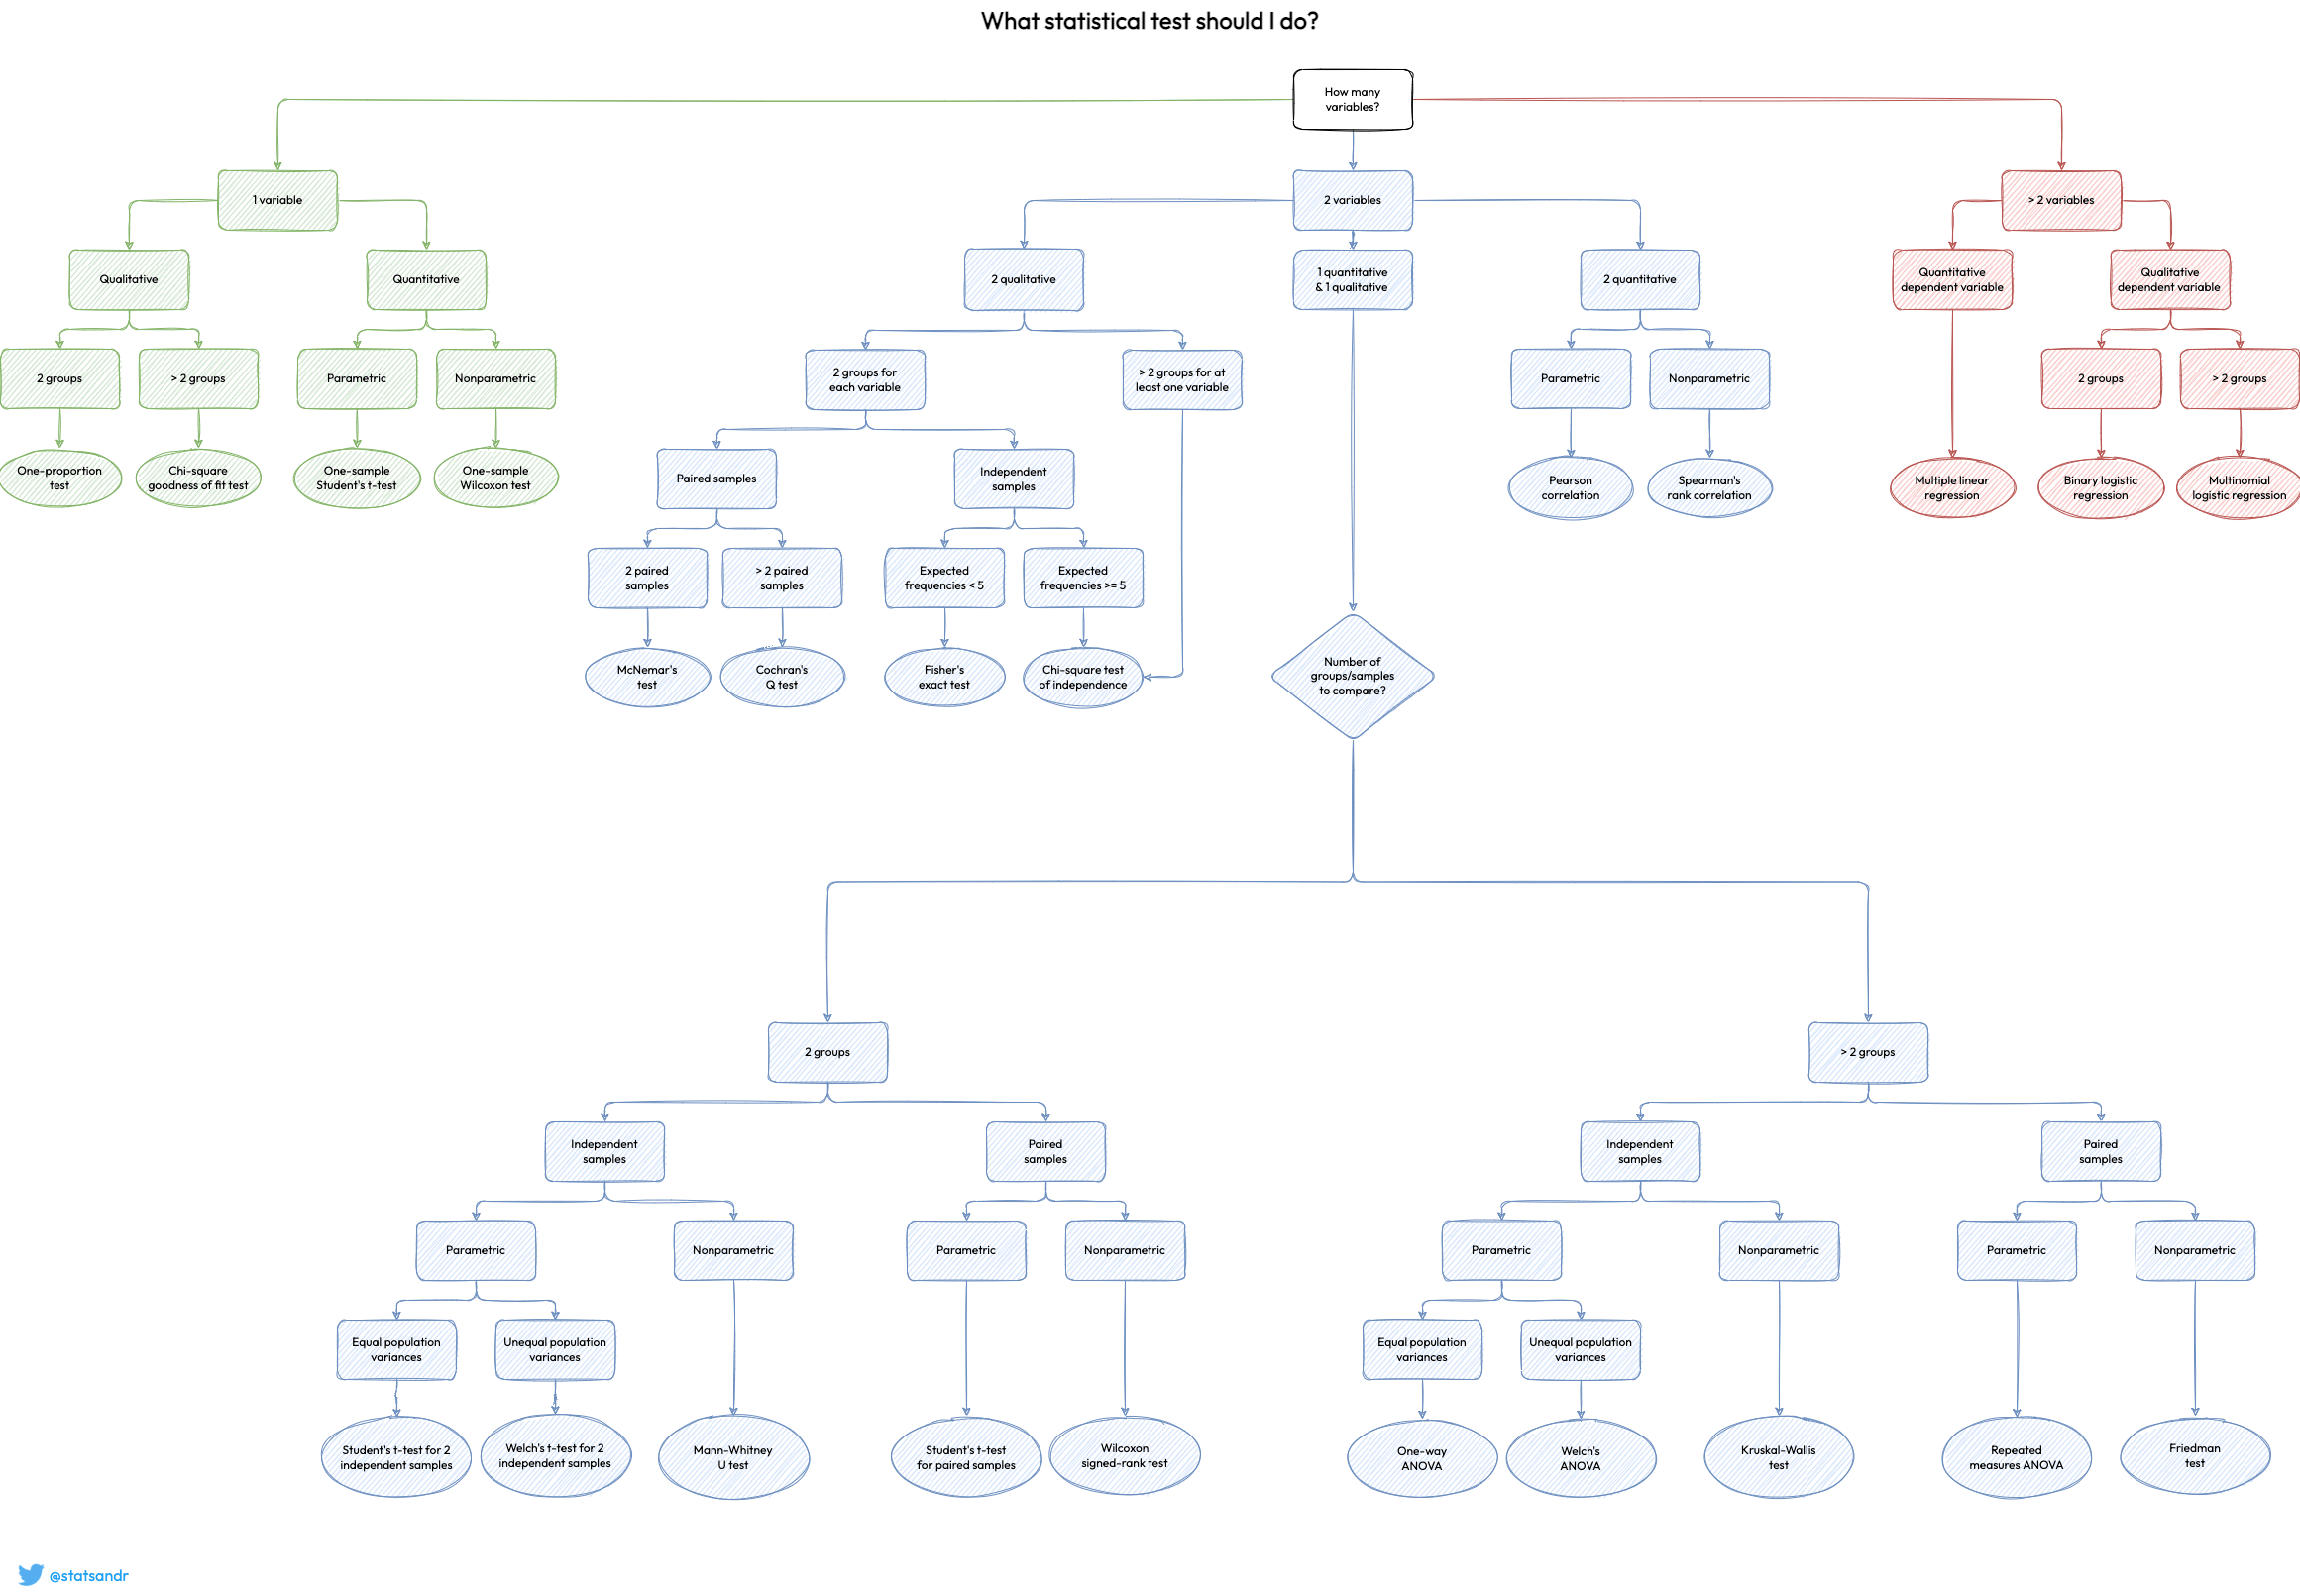

In [11]:
from IPython.display import Image
Image("../holy_grail_of_statistical_test_decision.png")

### H1: Overall Sign-Up Rate

In [12]:
print("=== H1: any_signup (pooled) ===")
stat_h1, p_h1, dof_h1 = chi2_test(df, outcome='any_signup', group_col='treatment')
chi2_power_report(chi2_stat=stat_h1, N=len(df), dof=dof_h1)

=== H1: any_signup (pooled) ===
Chi2: 1.5718, dof: 1, p-value: 0.20994, Cohen's w: 0.0177
Fail to reject the null hypothesis: no significant association between 'any_signup' and 'treatment'.

        Inconclusive (power=0.24): not significant, but observed w=0.018 is below the MDE w=0.040, 
        so the test was too weak to detect it. Absence of evidence is not evidence of absence. Need ~24967 total for power=0.8.


,question,value
0,observed effect (Cohen's w),0.017730
1,MDE: smallest detectable w at N=5000,0.039620
2,power at the observed effect,0.240675
3,N needed for power=0.8,24967.353914


In [13]:
for country in ['Italy', 'Spain']:
    subset = df[df['country'] == country]
    print(f"\n=== H1: any_signup ({country}, n={len(subset):,}) ===")
    stat, p, dof = chi2_test(subset, outcome='any_signup', group_col='treatment')
    chi2_power_report(chi2_stat=stat, N=len(subset), dof=dof)


=== H1: any_signup (Italy, n=2,530) ===
Chi2: 1.3002, dof: 1, p-value: 0.25418, Cohen's w: 0.0227
Fail to reject the null hypothesis: no significant association between 'any_signup' and 'treatment'.

        Inconclusive (power=0.21): not significant, but observed w=0.023 is below the MDE w=0.056, 
        so the test was too weak to detect it. Absence of evidence is not evidence of absence. Need ~15273 total for power=0.8.

=== H1: any_signup (Spain, n=2,470) ===
Chi2: 0.3385, dof: 1, p-value: 0.56068, Cohen's w: 0.0117
Fail to reject the null hypothesis: no significant association between 'any_signup' and 'treatment'.

        Inconclusive (power=0.09): not significant, but observed w=0.012 is below the MDE w=0.056, 
        so the test was too weak to detect it. Absence of evidence is not evidence of absence. Need ~57267 total for power=0.8.


### H2: On-Target (Creative-Aligned) Sign-Up Rate

In [14]:
print("=== H2: target_signup (pooled) ===")
stat_h2, p_h2, dof_h2 = chi2_test(df, outcome='target_signup', group_col='treatment')
chi2_power_report(chi2_stat=stat_h2, N=len(df), dof=dof_h2)

=== H2: target_signup (pooled) ===
Chi2: 94.0054, dof: 1, p-value: 0.00000, Cohen's w: 0.1371
Reject the null hypothesis: 'target_signup' is associated with 'treatment'.

        Significant and well-powered (power=1.00): observed w=0.137 is above the MDE w=0.040. 
        Reliable association, trust the result.


,question,value
0,observed effect (Cohen's w),0.137117
1,MDE: smallest detectable w at N=5000,0.039620
2,power at the observed effect,1.000000
3,N needed for power=0.8,417.468638


In [15]:
for country in ['Italy', 'Spain']:
    subset = df[df['country'] == country]
    print(f"\n=== H2: target_signup ({country}, n={len(subset):,}) ===")
    stat, p, dof = chi2_test(subset, outcome='target_signup', group_col='treatment')
    chi2_power_report(chi2_stat=stat, N=len(subset), dof=dof)


=== H2: target_signup (Italy, n=2,530) ===
Chi2: 54.6312, dof: 1, p-value: 0.00000, Cohen's w: 0.1469
Reject the null hypothesis: 'target_signup' is associated with 'treatment'.

        Significant and well-powered (power=1.00): observed w=0.147 is above the MDE w=0.056. 
        Reliable association, trust the result.

=== H2: target_signup (Spain, n=2,470) ===
Chi2: 39.0102, dof: 1, p-value: 0.00000, Cohen's w: 0.1257
Reject the null hypothesis: 'target_signup' is associated with 'treatment'.

        Significant and well-powered (power=1.00): observed w=0.126 is above the MDE w=0.056. 
        Reliable association, trust the result.


### H3: Full Outcome Distribution (3-Way)

In [16]:
outcomes = ['no_signup', 'target_signup', 'cross_signup']

print("=== H3: full outcome distribution (pooled) ===")
stat_h3, p_h3, dof_h3 = chi2_test(df, outcome=outcomes, group_col='treatment')
chi2_power_report(chi2_stat=stat_h3, N=len(df), dof=dof_h3)

=== H3: full outcome distribution (pooled) ===
Chi2: 147.1707, dof: 2, p-value: 0.00000, Cohen's w: 0.1716
Reject the null hypothesis: '['no_signup', 'target_signup', 'cross_signup']' is associated with 'treatment'.

        Significant and well-powered (power=1.00): observed w=0.172 is above the MDE w=0.044. 
        Reliable association, trust the result.


,question,value
0,observed effect (Cohen's w),0.171564
1,MDE: smallest detectable w at N=5000,0.043897
2,power at the observed effect,1.000000
3,N needed for power=0.8,327.330417


In [17]:
for country in ['Italy', 'Spain']:
    subset = df[df['country'] == country]
    print(f"\n=== H3: full outcome distribution ({country}, n={len(subset):,}) ===")
    stat, p, dof = chi2_test(subset, outcome=outcomes, group_col='treatment')
    chi2_power_report(chi2_stat=stat, N=len(subset), dof=dof)


=== H3: full outcome distribution (Italy, n=2,530) ===
Chi2: 84.4359, dof: 2, p-value: 0.00000, Cohen's w: 0.1827
Reject the null hypothesis: '['no_signup', 'target_signup', 'cross_signup']' is associated with 'treatment'.

        Significant and well-powered (power=1.00): observed w=0.183 is above the MDE w=0.062. 
        Reliable association, trust the result.

=== H3: full outcome distribution (Spain, n=2,470) ===
Chi2: 63.4447, dof: 2, p-value: 0.00000, Cohen's w: 0.1603
Reject the null hypothesis: '['no_signup', 'target_signup', 'cross_signup']' is associated with 'treatment'.

        Significant and well-powered (power=1.00): observed w=0.160 is above the MDE w=0.062. 
        Reliable association, trust the result.


### Residual Analysis: What Drives the Difference?

Adjusted standardised residuals show which cells in the H3 contingency table are responsible for the overall result. Values with |residual| > 2 are meaningful (positive = above expected, negative = below).

,no_signup,target_signup,cross_signup
treatment,,,
Metal,1.29,-9.74,8.34
Standard,-1.29,9.74,-8.34


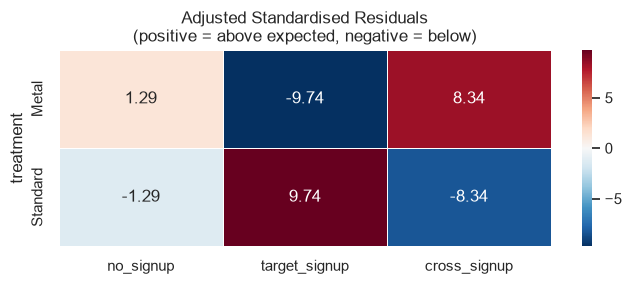

In [18]:
residuals = chi2_residuals(df, outcome=outcomes, group_col='treatment')
display(residuals.round(2))

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    residuals, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5, ax=ax
)
ax.set_title('Adjusted Standardised Residuals\n(positive = above expected, negative = below)')
plt.tight_layout()
plt.show()

---

## Interpretation

### Overall sign-up rate: inconclusive

H1 is not significant (p = 0.21, Cohen's w = 0.018, power = 24%). Both campaigns produced a similar overall sign-up rate (~20-22%). But this is inconclusive, not equivalent. The test was structurally too small to detect an effect this size. We would need ~25,000 users to reliably detect it. Not significant does not mean the same; it means we cannot tell.

Country-level results are consistent: neither Italy nor Spain shows a significant H1 result. The pooling assumption holds for this metric.

### On-target conversion: Standard wins clearly

H2 is significant (p < 0.001, Cohen's w = 0.14, power = 100%). Standard produced a target sign-up rate of 15.3% vs 6.7% for Metal. The result is well-powered and replicates in both markets (Italy: w = 0.15, Spain: w = 0.13). The direction and magnitude are consistent. This is not a pooling artefact.

### Full outcome distribution: strong and consistent

H3 is significant (p < 0.001, Cohen's w = 0.17, power = 100%). The residuals show exactly what is happening:

| Cell | Residual | Interpretation |
|------|----------|----------------|
| Standard -> `target_signup` | +9.7 | Standard converts strongly to its own product |
| Metal -> `cross_signup` | +8.3 | Metal-exposed users convert to Standard instead |
| Standard -> `cross_signup` | -8.3 | Standard-exposed users rarely switch to Metal |
| Metal -> `target_signup` | -9.7 | Metal underperforms on its own product |

Metal-exposed users signed up for Standard at 13.8%, vs only 6.7% for Metal itself. The Metal creative was, in practice, a Standard acquisition channel.

H3 holds in both Italy and Spain. The pattern is not market-specific.

### What this actually means

Standard outperforms Metal on every metric that directly measures creative effectiveness. Attributing the full gap to the creative alone would be an overreach though.

Metal is a premium product. The Facebook audience reached here may not be ready to pay for it regardless of ad quality. Metal-exposed users converting to Standard could be a product-market fit problem, not a creative one. Different root causes, different solutions. Redesigning the ad only fixes the first.

The dataset does not have enough information to separate these two hypotheses. There is no data on price sensitivity, drop-off at the paywall, CTR, or post-click behaviour.

> **Recommendation**: Scale the Standard creative. Instrument the post-click funnel before changing Metal. Creative drop-off and paywall drop-off need different fixes.

---

## What I Would Improve

### Pre-register the primary metric

I tested three outcomes here. Without pre-registration, there is a risk of selecting the most favourable result after the fact. Future experiments should commit to one primary metric upfront. I would recommend `target_signup`, with the others as pre-specified secondaries. But, when we do this, we have to make sure that the users are not landing on the same screen in product. Without this alignment with the product, the cross-cannibalization will be inevitable, and the inference of the creative performance will be biased again.

### Add a holdout group

There is no control group in this experiment. Without a holdout, we cannot measure true incremental lift or separate organic signups from campaign-driven ones.

Post-iOS14 or enforced untracability, individual-level holdouts on Meta and basically everywhere are unreliable. A **geo-based holdout** would be more robust: withhold paid social from randomly selected regions and compare aggregate signup rates. No user-level tracking needed, no ATT framework problem. The tradeoff is that geographies are not identical populations, so pre-campaign baseline matching between holdout and exposed regions is essential.

### Use first transaction as the conversion event

If this were a conversion campaign, signup is the wrong optimisation signal. Meta finds the cheapest-to-register audience, not the most valuable one. From Task 1, 63% of signups never transact. The algorithm steers toward the wrong population. First transaction, or at minimum KYC completion, would fix that. If we pay conversion-CPAs, we want to acquire people who are likely to convert. We can even discuss metal-first-transaction event here.

### Enforce product-specific paywall routing

If we run separate campaigns for Metal and Standard, the signup flow should enforce that intent. A Metal ad click should land on a Metal-specific page. Without this, `cross_signup` measures paywall design, not user preference. Fixing it makes `target_signup` a cleaner signal.

### Instrument the full funnel

Signup is the first step. Adding downstream events (KYC completion, card activation, first transaction) would tell us whether both creatives attract users of similar quality. More signups with fewer activations is not better, just noise.

### Power-size the experiment before launch

With 5,000 users, H1 had only 24% power. We needed ~25,000 to detect the observed effect. A power calculation before launch would have caught that. For the `target_signup` effect we observed (w = 0.14), ~420 users would have been enough. For smaller effects, considerably more.